In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *

In [2]:
#File names:
DIR = "Data DESI/"
outputDIR = DIR + "DESI Figures/" #to save figures
output_path = outputDIR + "DESI_DR1_Spectr_" #common suffix to every figures
FILE_BGS = DIR + "coadd-main-bright-26033.fits"
FILE_QSO = DIR + "coadd-main-dark-26033.fits"

#Reading files:
BGS = fitsio.FITS(FILE_BGS)
QSO = fitsio.FITS(FILE_BGS)
BGS


  file: Data DESI/coadd-main-bright-26033.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      FIBERMAP
  2      BINARY_TBL      EXP_FIBERMAP
  3      IMAGE_HDU       B_WAVELENGTH
  4      IMAGE_HDU       B_FLUX
  5      IMAGE_HDU       B_IVAR
  6      IMAGE_HDU       B_MASK
  7      IMAGE_HDU       B_RESOLUTION
  8      IMAGE_HDU       R_WAVELENGTH
  9      IMAGE_HDU       R_FLUX
  10     IMAGE_HDU       R_IVAR
  11     IMAGE_HDU       R_MASK
  12     IMAGE_HDU       R_RESOLUTION
  13     IMAGE_HDU       Z_WAVELENGTH
  14     IMAGE_HDU       Z_FLUX
  15     IMAGE_HDU       Z_IVAR
  16     IMAGE_HDU       Z_MASK
  17     IMAGE_HDU       Z_RESOLUTION
  18     BINARY_TBL      SCORES

In [3]:
BGS_FIBER, QSO_FIBER = Table(BGS['FIBERMAP'].read()), Table(QSO['FIBERMAP'].read())
BGS_FIBER.add_index('TARGETID')
QSO_FIBER.add_index('TARGETID')
BGS_FIBER

TARGETID,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MEAN_PSF_TO_FIBER_SPECFLUX
int64,int32,float64,float64,float32,float32,float32,int64,uint8,str3,float64,int32,int16,str8,int32,int32,str4,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int64,float64,float64,int16,float32,int16,int16,float32,float32,float32,float32,float64,float32,float64,float32,float32
-201110070,10,209.4276489319061,1.1371637827783927,0.0,0.0,0.0,0,4,SKY,0.0,0,0,,0,0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,,0,0,0,0,0,0,209.4276489319061,1.1371637827783927,1,535.7306,1,1,0.006,0.006,0.008,0.008,209.42767349443702,0.0,1.1371312855935212,0.0,0.79153967
616088570741915866,0,209.44375282190077,1.1691067122754568,0.0,0.0,0.0,4294967296,4,SKY,0.9706703874505291,63,9010,2093p012,338405,218,,0.03504059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.012128939,-0.007254964,-0.01966214,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,,-1,-1,4294967296,0,0,0,209.44375282190077,1.1691067122754568,1,535.7306,1,1,0.0,0.0,0.0,0.0,209.443752821901,0.0,1.16910671227546,0.0,0.7907525
39627818438496481,0,209.43711667210977,1.2309857307903003,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.5419477814762501,516,9010,2093p012,338405,4321,SER,0.035188664,12.181779,52.949505,113.80926,154.7863,105.0235,326.02023,76.42205,16.818794,1.2925214,0.4383064,3.5842924,15.57954,33.48654,3.5842924,15.57954,33.48654,0,2.1839783,1.29644,0.12115581,0.18338794,0,,0.0,0.0,0.0,0.0,S,2100,2,1152921504606846976,131074,0,0,209.43711667210977,1.2309857307903003,1,535.7306,1,1,-0.004,0.004,0.0,0.0,209.43710030070972,0.0,1.230985775778375,0.0,0.7661209
39627818438498091,0,209.49738771970516,1.1870353133578293,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.36789294176650633,516,9010,2093p012,338405,5931,DEV,0.035694785,4.445747,16.638227,36.66891,43.32471,23.141197,382.6697,104.51332,19.108404,1.4650887,0.42559972,1.1302931,4.230127,9.322757,1.1334926,4.243707,9.423918,0,4.0,2.1495562,-0.020623751,-0.40704092,0,,0.0,0.0,0.0,0.0,S,2100,2,1152921504606846976,131074,0,0,209.49738771970516,1.1870353133578293,1,535.7306,1,1,0.001,0.001,0.001,0.001,209.49739181253204,0.0,1.1870312410016877,0.0,0.76117635
39627830509701108,0,208.84084136090175,1.737851000427571,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.48139877646493534,516,9010,2088p017,341283,2036,SER,0.033804566,5.985449,17.322788,36.65425,49.620506,36.483875,380.48822,114.07417,19.064775,1.9811362,0.5218997,1.2911441,3.736765,7.9068294,1.2911441,3.736765,7.9068294,0,0.78791624,2.1865833,0.63836163,-0.16260311,0,,0.0,0.0,0.0,0.0,S,2100,2,1152921504606846976,131074,0,0,208.84084136090175,1.737851000427571,1,834.0196,1,1,0.0025127113,0.0025127113,0.0030821569,0.0030821569,208.84085140217326,0.0,1.7378395972040903,0.0,0.724707
39627830509700531,0,208.8135762496359,1.7490687818022774,0.0,0.0,2015.5,1152921504606846976,1,TGT,0.011713365843231682,516,9010,2088p017,341283,1459,REX,0.032699794,11.926736,29.199871,52.129177,57.15957,57.08422,149.09227,48.24043,7.7890563,1.6182747,0.4209065,1.208528,2.958803,5.282214,1.2089473,2.959195

## Data exoloration

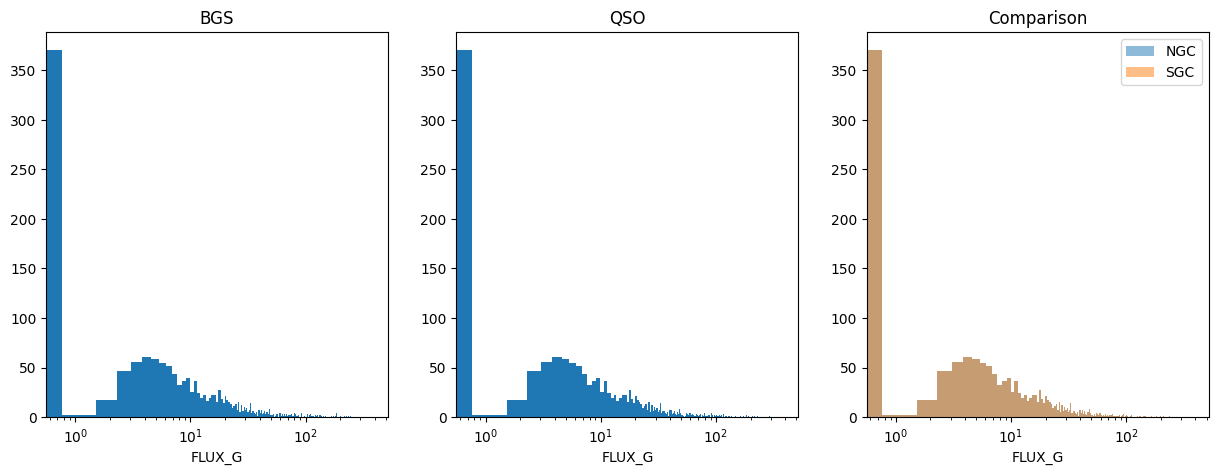

In [4]:
def recenter_RA(RA):
    return np.where(RA > 180,RA - 360, RA)


def plot_RADEC(RA, DEC, title='', RA_recenter=True, all_sky=True, **kwargs):
    if "figax" in kwargs.keys(): fig, ax = kwargs.pop("figax")
    else: fig, ax = plt.subplots()
    grid = kwargs.pop("grid", False)
    if RA_recenter: #make 360° correspond with 0°
        RA = RA.copy() #to not affect the data itself
        RA = recenter_RA(RA)
        RA_ticks = np.arange(-180, 201, 60)
        RA_labels = (RA_ticks + 360) % 360
    else:
        RA_ticks = np.arange(0, 361, 60)
        RA_labels = RA_ticks
    DEC_ticks = np.arange(-90, 91, 30)
    ax.scatter(RA, DEC, edgecolors='white', linewidths=0.1)
    if all_sky or RA_recenter:
        ax.set_xticks(RA_ticks)
        ax.set_xticklabels(RA_labels)
    if all_sky: ax.set_yticks(DEC_ticks)
    ax.invert_xaxis()
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC")
    if grid: ax.grid()


def histCompare_BQ(col, xlabel, category=False, **kwargs):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    xscale = kwargs.pop('xscale', "linear")
    if category: #qualitative variables
        sns.countplot(BGS_FIBER[[col]].to_pandas(), x=col, ax=ax[0])
        ax[0].set_title("BGS")
        sns.countplot(QSO_FIBER[[col]].to_pandas(), x=col, ax=ax[1])
        ax[1].set_title("QSO")
        sns.countplot(BGS_FIBER[[col]].to_pandas(), x=col, ax=ax[2], label="NGC", alpha=0.5)
        sns.countplot(QSO_FIBER[[col]].to_pandas(), x=col, ax=ax[2], label="SGC", alpha=0.5)
        ax[2].set_title("Comparison")
    else: #quantitative variables
        get_hist(BGS_FIBER[col], xlabel=xlabel, title="BGS", show=False, figax = (fig, ax[0]), **kwargs)
        get_hist(QSO_FIBER[col], xlabel=xlabel, title="QSO", show=False, figax = (fig, ax[1]), **kwargs)
        get_hist(BGS_FIBER[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="NGC", alpha=0.5, **kwargs)
        get_hist(QSO_FIBER[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="SGC", alpha=0.5, **kwargs)
        ax[2].legend()
        ax[0].set_xscale(xscale)
        ax[1].set_xscale(xscale)
        ax[2].set_xscale(xscale)
    return fig, ax

histCompare_BQ("FLUX_G", "FLUX_G", bins=500, xscale="log");

## Common TARGETID

### On BGS:

In [23]:
FILE_BGS_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_BGS_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"
BGS_NGC = Table.read(FILE_BGS_NGC)
BGS_SGC = Table.read(FILE_BGS_SGC)

#Common TARGETID
mask_BGS = np.isin(BGS_FIBER['TARGETID'], BGS_NGC['TARGETID']) | np.isin(BGS_FIBER['TARGETID'], BGS_SGC['TARGETID'])
BGS_ID = BGS_FIBER[mask_BGS]['TARGETID']
BGS_ID

39627818438496481
39627818438498091
39627830509701108
39627830509700531
39627830509701407
39627830509700390
39627830509702937
39627818421717700
39627818417525727
39627818421715497
39627818417525710


### On QSO:

In [24]:
FILE_QSO_NGC = DIR + "QSO_NGC_clustering.dat.fits"
FILE_QSO_SGC = DIR + "QSO_SGC_clustering.dat.fits"
QSO_NGC = Table.read(FILE_QSO_NGC)
QSO_SGC = Table.read(FILE_QSO_SGC)

#Common TARGETID
mask_QSO = np.isin(QSO_FIBER['TARGETID'], QSO_NGC['TARGETID']) | np.isin(QSO_FIBER['TARGETID'], QSO_SGC['TARGETID'])
QSO_ID = QSO_FIBER[mask_QSO]['TARGETID']
QSO_ID

39627806350511669
39627812394504418
39627824469901901
39627818438494046


## Spectra

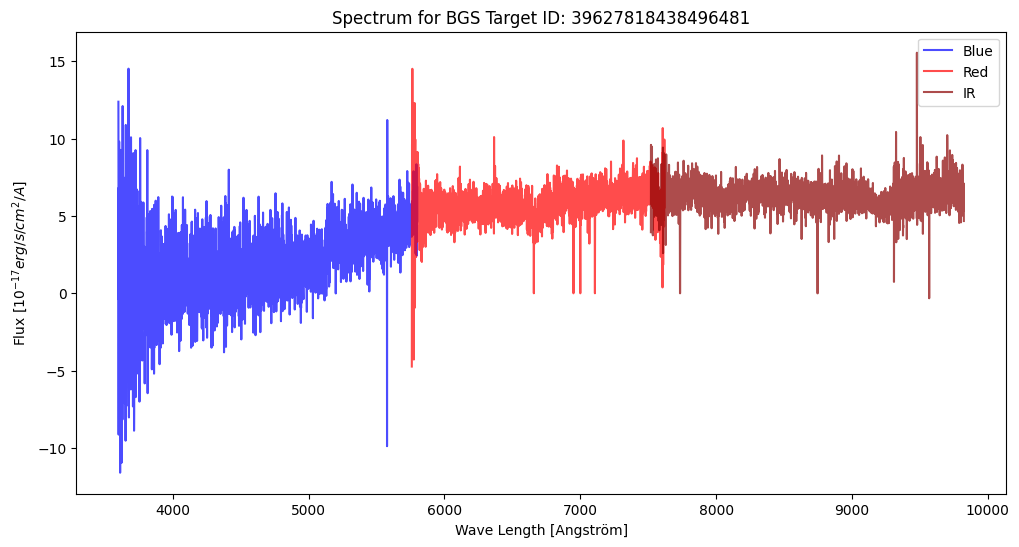

In [25]:
def plot_spectrum(data, target_ID, cat):
    idx = np.where(data['FIBERMAP']['TARGETID'].read() == target_ID)[0][0]
    
    wave_b = data['B_WAVELENGTH'].read()
    wave_r = data['R_WAVELENGTH'].read()
    wave_z = data['Z_WAVELENGTH'].read()
    
    flux_b = data['B_FLUX'].read()
    flux_r = data['R_FLUX'].read()
    flux_z = data['Z_FLUX'].read()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(wave_b, flux_b[idx], label='Blue', color='blue', alpha=0.7)
    ax.plot(wave_r, flux_r[idx], label='Red', color='red', alpha=0.7)
    ax.plot(wave_z, flux_z[idx], label='IR', color='darkred', alpha=0.7)
    
    ax.set_title(f"Spectrum for {cat} Target ID: {target_ID}")
    ax.set_xlabel("Wave Length [Angström]")
    ax.set_ylabel("Flux $[10^{-17} erg/s/cm^2/A]$")
    ax.legend()
    return fig, ax

target_ID = BGS_ID[0]
plot_spectrum(BGS, target_ID, 'BGS');

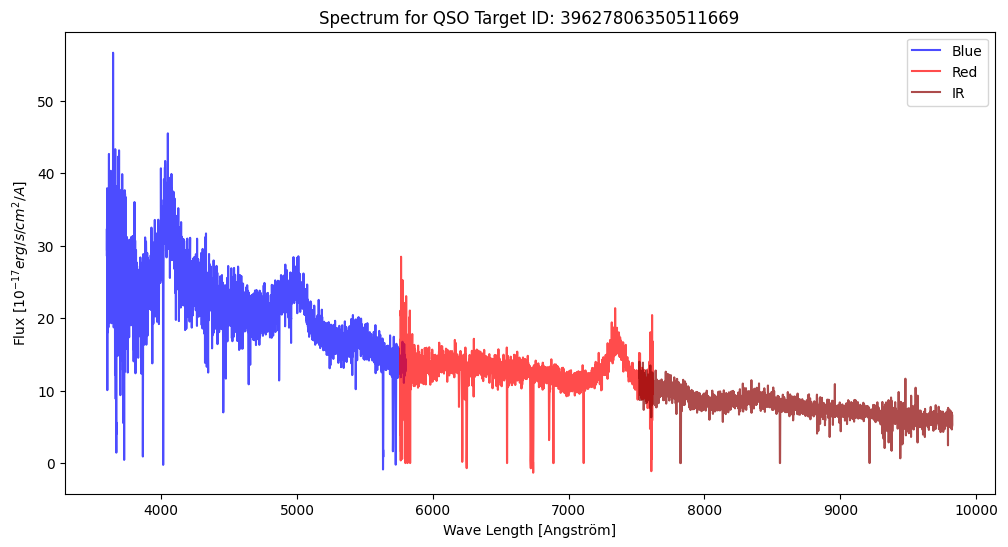

In [26]:
target_ID = QSO_ID[0]
plot_spectrum(QSO, target_ID, 'QSO');

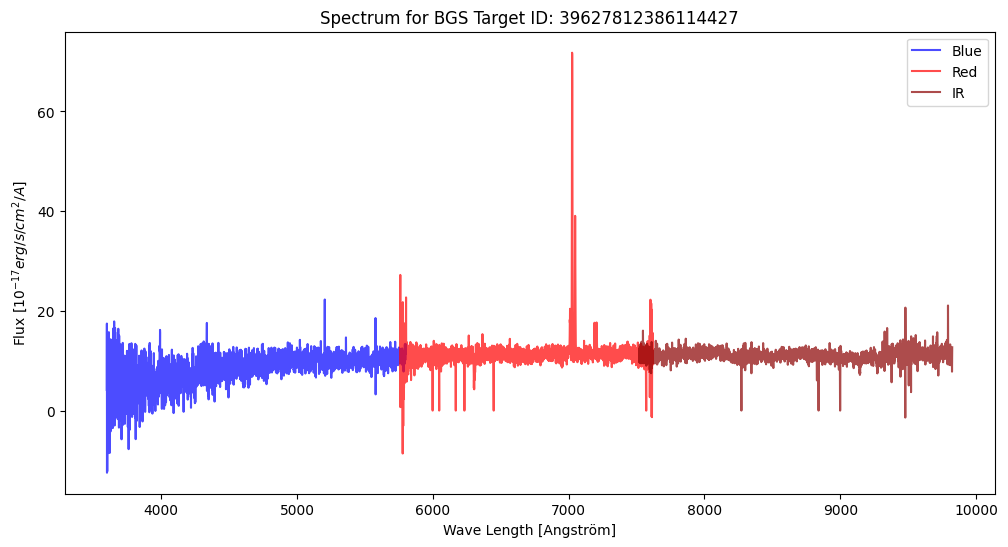

In [51]:
def get_max(data, col, sheet="FIBERMAP", **kwargs):
    sheet = data[sheet].read(columns=['TARGETID', col])
    mask = kwargs.pop('mask', np.array([True]*len(sheet)))
    sheet = sheet[mask]
    col = sheet[col]
    idx = np.nanargmax(col)
    target_id = sheet['TARGETID'][idx]
    return target_id

target_ID = get_max(BGS, 'FLUX_R', mask=mask_BGS)
plot_spectrum(BGS, target_ID, 'BGS');

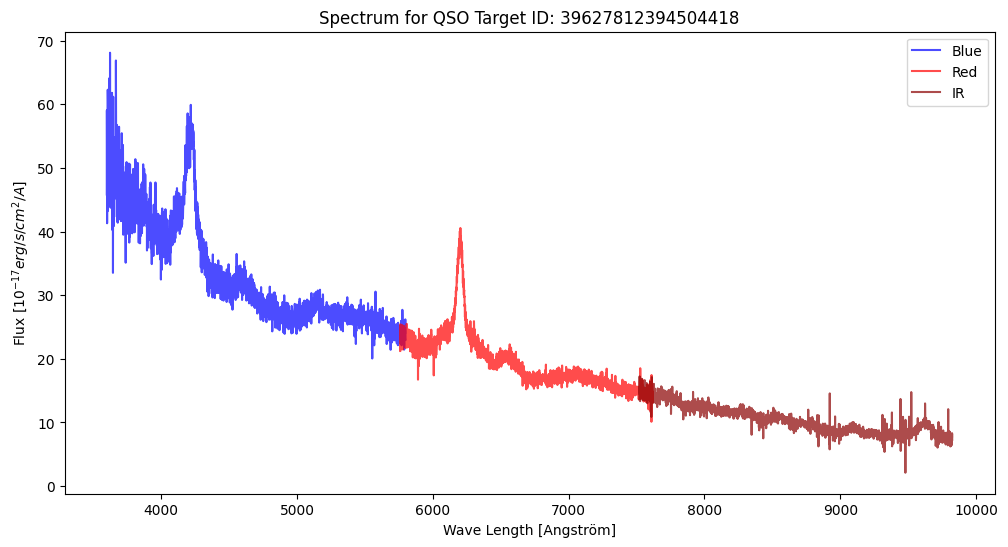

In [52]:
target_ID = get_max(QSO, 'FLUX_R', mask=mask_QSO)
plot_spectrum(QSO, target_ID, 'QSO');

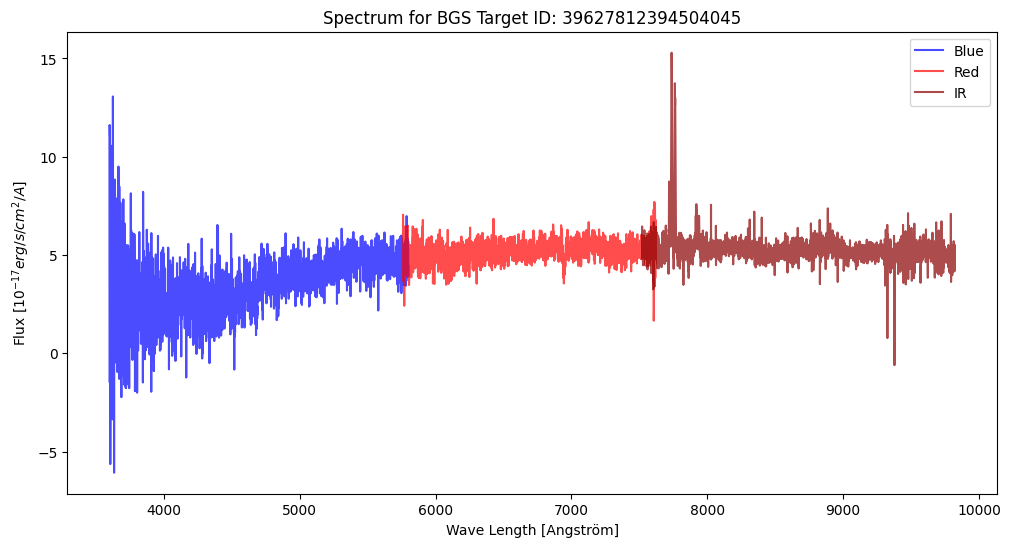

In [53]:
target_ID = get_max(BGS, 'TSNR2_BGS',"SCORES", mask=mask_BGS)
plot_spectrum(BGS, target_ID, 'BGS');

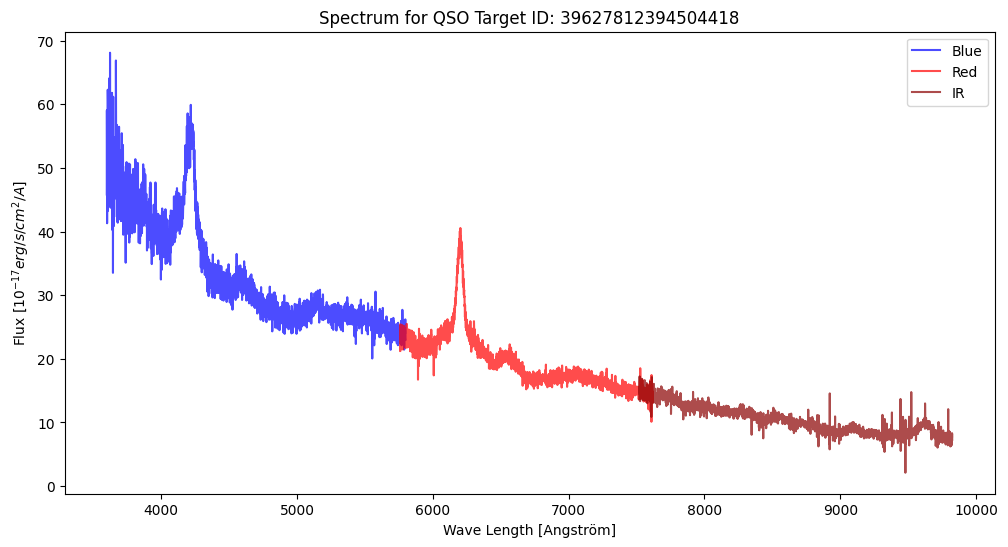

In [55]:
target_ID = get_max(QSO, 'TSNR2_QSO',"SCORES", mask=mask_QSO)
plot_spectrum(QSO, target_ID, 'QSO');